<a href="DNN4HEP_lightning.ipynb" download>⬇ Click here to download this notebook</a>

# Rebuilding the HEP DNN with PyTorch Lightning

This notebook takes the binary classifier from `DNN4HEP_exercise.ipynb` (Higgs-to-two-leptons
signal vs. top-pair background) and rebuilds the **exact same model and data pipeline** using
[PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/).

The goal isn't a different DNN &mdash; it's to see how the same ingredients (data, architecture, loss,
optimizer) map onto Lightning's structure, and which pieces of hand-written boilerplate Lightning
takes over for you:

| Manual PyTorch (previous notebook) | PyTorch Lightning (this notebook) |
|---|---|
| `for epoch in range(N): ...` training loop | `Trainer.fit(model, datamodule)` |
| Manually calling `model.train()` / `model.eval()` | Handled automatically per step |
| Manually looping `train_loader`, `val_loader` | `training_step` / `validation_step` hooks |
| Manual early-stopping class + `if ... break` | `EarlyStopping` callback |
| Manually moving tensors to GPU/CPU | Handled automatically by the `Trainer` |
| Appending losses to a list, then `plt.plot` | Built-in logging (`self.log(...)`) + a logger (here: CSV) |
| Re-running cells to reset weights | Re-instantiate the `LightningModule` |

We reuse the same dataset, the same 26 HEP features, the same `Linear-Sigmoid` architecture from the
solutions notebook, and the same evaluation (ROC curve, accuracy/precision/recall/F1, permutation
feature importance), so you can compare this notebook cell-for-cell against the original.


In [1]:
# If running this on Colab, or lightning isn't installed yet, uncomment:
# %pip install lightning h5py scikit-learn


In [2]:
import io
import os

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score,
)

pl.seed_everything(42, workers=True)


Seed set to 42


42

## 1. Data

Same dataset as before: 26 features per event, `Signal` (Higgs &rarr; 2 leptons) vs. `Background`
(top-quark pair), stored in `WW_vs_TT_dataset.h5`.

If you've already downloaded the data for the previous exercise it will be sitting in `../data/`,
so we use that if present and fall back to the CERNBox download otherwise.


In [3]:
local_path = "../data/WW_vs_TT_dataset.h5"

if os.path.exists(local_path):
    print(f"Loading local file: {local_path}")
    h5_source = local_path
else:
    url = "https://cernbox.cern.ch/remote.php/dav/public-files/icjK5HWChdTcdb2/WW_vs_TT_dataset.h5"
    print(f"Local file not found, downloading from {url}")
    import requests
    response = requests.get(url)
    response.raise_for_status()
    h5_source = io.BytesIO(response.content)

file = h5py.File(h5_source, 'r')
df_signal     = pd.DataFrame(file['Signal'][:])
df_background = pd.DataFrame(file['Background'][:])

df_signal.shape, df_background.shape


Loading local file: ../data/WW_vs_TT_dataset.h5


((178116, 26), (200000, 26))

In [4]:
# Use all 26 features, as in the solutions notebook. Feel free to swap in your own
# `input_features` subset from the exercise notebook here instead.
input_features = list(df_signal.columns)

df_signal_filtered     = df_signal[input_features]
df_background_filtered = df_background[input_features]

y_signal     = np.ones(len(df_signal_filtered))
y_background = np.zeros(len(df_background_filtered))

input_data = np.concatenate((df_signal_filtered, df_background_filtered), axis=0)
target     = np.concatenate((y_signal, y_background), axis=0)

N_features = len(input_features)
print(f"{N_features} input features, {len(target)} events total")


26 input features, 378116 events total


In [5]:
# 80 / 10 / 10 train / val / test split, same as the exercise
X_train, X_temp, y_train, y_temp = train_test_split(
    input_data, target, test_size=0.2, shuffle=True, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=True, random_state=42
)

# Standardise using statistics from the training set only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val,   dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32)

X_train_tensor.shape, X_val_tensor.shape, X_test_tensor.shape


(torch.Size([302492, 26]), torch.Size([37812, 26]), torch.Size([37812, 26]))

## 2. A `LightningDataModule`

A `LightningDataModule` bundles everything about your data &mdash; here, simply the three
`TensorDataset`s and how to turn them into `DataLoader`s &mdash; so the `Trainer` can ask for
`train_dataloader()` / `val_dataloader()` / `test_dataloader()` without the training code needing
to know anything about where the data came from.

We've already done the loading/splitting/scaling above (identical to the exercise), so this
`DataModule` is intentionally thin: it just wraps the pre-built tensors. You could equally move the
whole data-preparation cell above into `setup()` if you wanted the DataModule to be fully
self-contained.


In [6]:
class HEPDataModule(pl.LightningDataModule):
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=4096, num_workers=0):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_dataset = TensorDataset(X_train, y_train)
        self.val_dataset   = TensorDataset(X_val, y_val)
        self.test_dataset  = TensorDataset(X_test, y_test)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size,
                           shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size,
                           shuffle=False, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size,
                           shuffle=False, num_workers=self.num_workers)

    def predict_dataloader(self):
        # same as test, kept unshuffled so predictions line up with y_test
        return self.test_dataloader()


datamodule = HEPDataModule(
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    X_test_tensor, y_test_tensor,
    batch_size=4096,
)


## 3. The DNN as a `LightningModule`

A `LightningModule` *is* an `nn.Module` (you can still call `model(x)` directly), plus a handful of
extra hooks that tell the `Trainer` what to do on each batch:

- `forward` &mdash; the same forward pass as `SimpleDNN` in the exercise notebook.
- `training_step` / `validation_step` / `test_step` &mdash; replace the bodies of the manual
  `for inputs, targets in loader:` loops. Whatever you return/log here is what the `Trainer`
  reports.
- `configure_optimizers` &mdash; replaces the standalone `optimizer = optim.Adam(...)` cell. This is
  also where an LR scheduler would go (see the bonus cell below).

The architecture mirrors the `nn.Sequential` model from the solutions notebook
(`Linear(N,100) -> Sigmoid -> Linear(100,50) -> Sigmoid -> Linear(50,1) -> Sigmoid`, trained with
`BCELoss`), with an optional `dropout` argument so you can reproduce the "Use Dropout" bonus task
just by passing `dropout=0.2` when you build the model.


In [7]:
class LightningDNN(pl.LightningModule):
    def __init__(self, n_features, hidden1=100, hidden2=50, dropout=0.0,
                 lr=1e-3, weight_decay=0.0, use_lr_scheduler=False):
        super().__init__()
        # save_hyperparameters() stores the constructor args (self.hparams.lr, etc.)
        # and logs them, so a checkpoint remembers exactly how the model was built.
        self.save_hyperparameters()

        self.net = nn.Sequential(
            nn.Linear(n_features, hidden1),
            nn.Sigmoid(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.Sigmoid(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
            nn.Sigmoid(),
        )
        self.criterion = nn.BCELoss()

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def _shared_step(self, batch):
        x, y = batch
        y = y.float()
        preds = self(x)
        loss = self.criterion(preds, y)
        acc = ((preds > 0.5).float() == y).float().mean()
        return loss, acc

    def training_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        # on_epoch=True aggregates over the epoch, replacing the manual
        # `running_loss += loss.item()` / `running_loss / len(loader)` bookkeeping.
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        self.log("test_loss", loss, on_step=False, on_epoch=True)
        self.log("test_acc", acc, on_step=False, on_epoch=True)
        return loss

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        x, _ = batch
        return self(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay
        )
        if not self.hparams.use_lr_scheduler:
            return optimizer

        # Bonus task equivalent: "adjust the learning rate during training".
        # ReduceLROnPlateau lowers lr when val_loss stops improving -- no manual
        # scheduler.step() calls needed, Lightning calls it for you.
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"},
        }


## 4. Training

This is what replaces the manual `for epoch in range(num_epochs): ...` loop, the
`model.train()`/`model.eval()` calls, and the hand-rolled `EarlyStopping` class from the bonus
tasks:

- `EarlyStopping(monitor="val_loss", patience=5)` is a drop-in replacement for the exercise's
  `EarlyStopping` class + `if early_stopping.early_stop: break`.
- `ModelCheckpoint` automatically saves the best-performing weights (by `val_loss`) to disk.
- `CSVLogger` records every value you passed to `self.log(...)` each epoch, which we'll use below
  to reproduce the training/validation loss plot.
- `accelerator="auto"` means this same code runs unchanged on CPU, a single GPU, or Apple Silicon
  (`mps`) &mdash; no manual `.to(device)` calls anywhere in the model or training step.


In [8]:
model = LightningDNN(n_features=N_features, dropout=0.0, lr=1e-3, use_lr_scheduler=False)

early_stopping = EarlyStopping(monitor="val_loss", patience=5, mode="min")
checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1, filename="best-{epoch}-{val_loss:.4f}")
lr_monitor = LearningRateMonitor(logging_interval="epoch")
logger = CSVLogger(save_dir="lightning_logs", name="DNN4HEP")

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices=1,
    callbacks=[early_stopping, checkpoint, lr_monitor],
    logger=logger,
    log_every_n_steps=1,
    enable_progress_bar=True,
)

trainer.fit(model, datamodule=datamodule)


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



  | Name      | Type       | Params | Mode  | FLOPs
---------------------------------------------------------
0 | net       | Sequential | 7.8 K  | train | 0    
1 | criterion | BCELoss    | 0      | train | 0    
---------------------------------------------------------
7.8 K     Trainable params
0         Non-trainable params
7.8 K     Total params
0.031     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


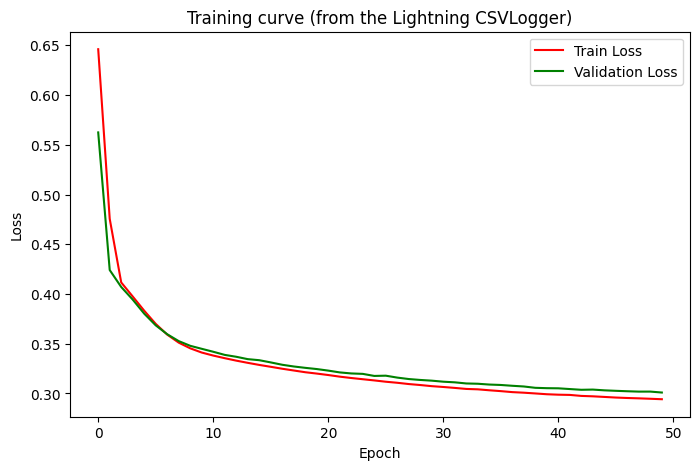

Best checkpoint: lightning_logs/DNN4HEP/version_0/checkpoints/best-epoch=49-val_loss=0.3009.ckpt
Best val_loss:   0.3009


In [9]:
# Plot the loss curve -- equivalent to the manual train_losses/val_losses lists + plt.plot,
# but the numbers come straight from what CSVLogger recorded via self.log(...) above.
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

train_loss = metrics.dropna(subset=["train_loss"])[["epoch", "train_loss"]]
val_loss   = metrics.dropna(subset=["val_loss"])[["epoch", "val_loss"]]

plt.figure(figsize=(8, 5))
plt.plot(train_loss["epoch"], train_loss["train_loss"], label="Train Loss", color="red")
plt.plot(val_loss["epoch"], val_loss["val_loss"], label="Validation Loss", color="green")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training curve (from the Lightning CSVLogger)")
plt.show()

print(f"Best checkpoint: {checkpoint.best_model_path}")
print(f"Best val_loss:   {checkpoint.best_model_score:.4f}")


## 5. Evaluation on the held-out test set

`trainer.test(...)` runs `test_step` over the test `DataLoader` and reports whatever was logged
there (loss, accuracy). For the score distributions, ROC curve and permutation importance we need
the raw per-event predictions, which we get from `trainer.predict(...)`.


In [10]:
test_metrics = trainer.test(model, datamodule=datamodule, verbose=True)


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8689040541648865
        test_loss           0.3003932535648346
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Predicting: |          | 0/? [00:00<?, ?it/s]

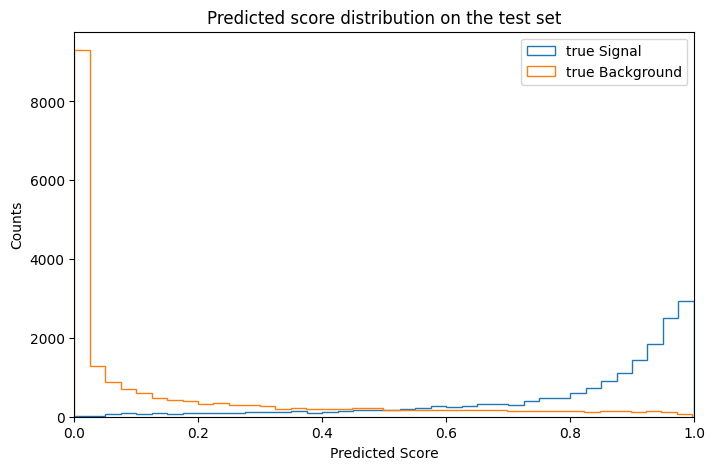

In [11]:
# Raw predicted scores on the test set, in the same order as X_test_tensor / y_test
predictions = trainer.predict(model, datamodule=datamodule)
y_pred = torch.cat(predictions).numpy()

true_signal = y_pred[y_test == 1]
true_bkg    = y_pred[y_test == 0]

plt.figure(figsize=(8, 5))
plt.hist(true_signal, bins=40, histtype="step", label="true Signal", density=False)
plt.hist(true_bkg, bins=40, histtype="step", label="true Background", density=False)
plt.legend()
plt.xlabel("Predicted Score")
plt.ylabel("Counts")
plt.xlim((0, 1))
plt.title("Predicted score distribution on the test set")
plt.show()


In [12]:
final_prediction = np.round(y_pred)

accuracy  = accuracy_score(y_test, final_prediction)
precision = precision_score(y_test, final_prediction, average="weighted")
recall    = recall_score(y_test, final_prediction, average="weighted")
f1        = f1_score(y_test, final_prediction, average="weighted")
roc_auc_value = roc_auc_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc_value:.4f}")


Accuracy:  0.8689
Precision: 0.8699
Recall:    0.8689
F1 Score:  0.8690
ROC AUC:   0.9429


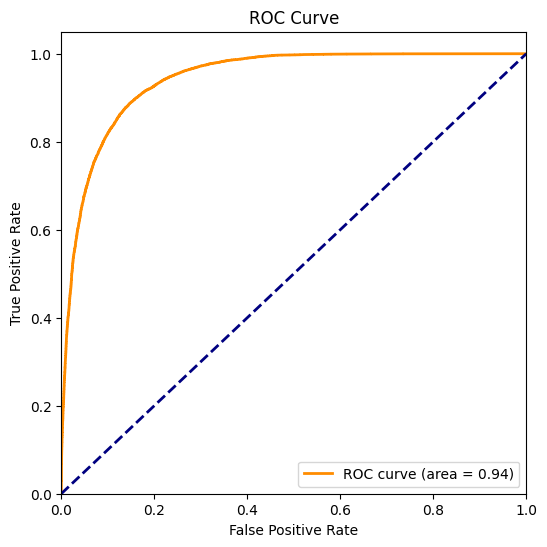

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


## 6. Permutation feature importance

The `LightningModule` is still an `nn.Module`, so the permutation-importance function from the
exercise notebook works completely unchanged &mdash; just call `model(x)` directly (Lightning
doesn't get in the way of using the model like a normal PyTorch model outside the `Trainer`).


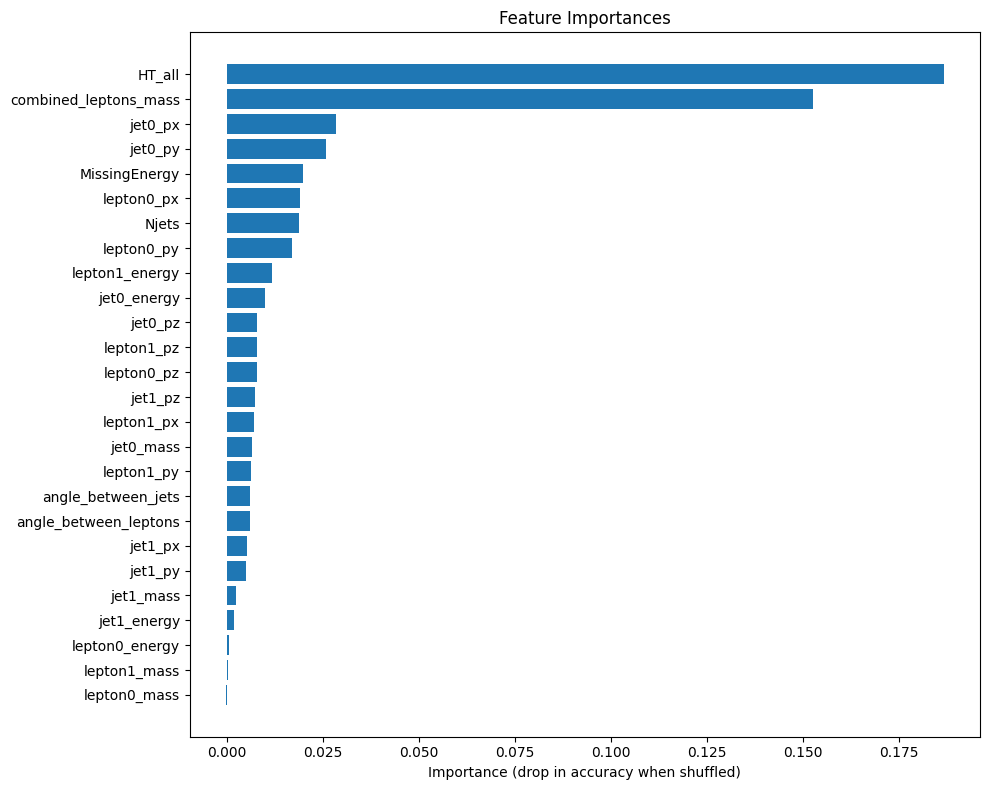

In [14]:
def permutation_importance(model, X_val_tensor, y_val):
    model.eval()
    detach_to_binary = lambda x: np.round(model(x).detach().numpy())

    baseline_score = accuracy_score(y_val, detach_to_binary(X_val_tensor))
    importances = []

    for feature_idx in range(X_val_tensor.shape[1]):
        X_val_shuffled = X_val_tensor.clone()
        X_val_shuffled[:, feature_idx] = X_val_shuffled[:, feature_idx][torch.randperm(X_val_tensor.shape[0])]

        score_shuffled = accuracy_score(y_val, detach_to_binary(X_val_shuffled))
        importances.append(baseline_score - score_shuffled)

    return np.array(importances)


importances = permutation_importance(model, X_val_tensor, y_val_tensor)

idx = np.argsort(importances)
sorted_features = np.array(input_features)[idx]
sorted_importances = importances[idx]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align="center")
plt.yticks(range(len(sorted_importances)), sorted_features)
plt.xlabel("Importance (drop in accuracy when shuffled)")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()


## 7. Loading the best checkpoint later

Because `ModelCheckpoint` saved the best-`val_loss` weights to disk, you don't need to keep this
notebook's `model` object around to reuse the trained network later &mdash; and unlike the manual
`.state_dict()` approach, the checkpoint also remembers the constructor arguments
(`n_features`, `dropout`, ...) that were passed via `save_hyperparameters()`:

```python
best_model = LightningDNN.load_from_checkpoint(checkpoint.best_model_path)
best_model.eval()
```

## Where to go from here

Everything in the exercise's "Bonus Tasks" section maps onto a small Lightning change rather than
rewritten training-loop code:

- **Early stopping** &rarr; already wired up above via the `EarlyStopping` callback.
- **LR scheduling** &rarr; set `use_lr_scheduler=True` when constructing `LightningDNN`.
- **Dropout** &rarr; set `dropout=0.2` (or similar) when constructing `LightningDNN`.
- **Different architecture / features** &rarr; change `hidden1`/`hidden2` in `LightningDNN`, or
  `input_features` back in Section 1, same as before.
- **Multiple optimizers/schedulers, gradient clipping, mixed precision, multi-GPU** &mdash; all
  available as `Trainer(...)` arguments (e.g. `precision="16-mixed"`, `devices=2`,
  `gradient_clip_val=1.0`) without touching `LightningDNN` at all.
